# <font color="purple">**2.3 Histogramas y Boxplots** </font>

La clase pasada vimos los primeros dos tipos de gráficas básicas. Ahora continuaremos con los **histogramas** (histogram) y los **gráficos de caja y bigotes** (boxplots).

In [1]:
#Primero vamos a importar todas las paqueterías necesarias para la clase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## <font color="darkblue"> **Histogramas de frecuencia**

Un *histograma* es una representación gráfica que nos permite ver la **distribución de las frecuencias de una muestra numérica**. Consiste en **dividir el rango de los datos en intervalos o clases (bins)** y contar cuántos datos caen dentro de cada intervalo. En apariencia, es similar a un gráfico de barras, sin embargo, en lugar de comparar categorías, *cada barra de un histograma representa cómo se distribuyen los datos en una única categoría*.

**Un histograma está compuesto por**:

* *Eje x*: intervalos de valores (bins o clases).

* *Eje y*: frecuencia (número de datos dentro del intervalo).

* *Barras*: representan la cantidad de observaciones en cada intervalo.

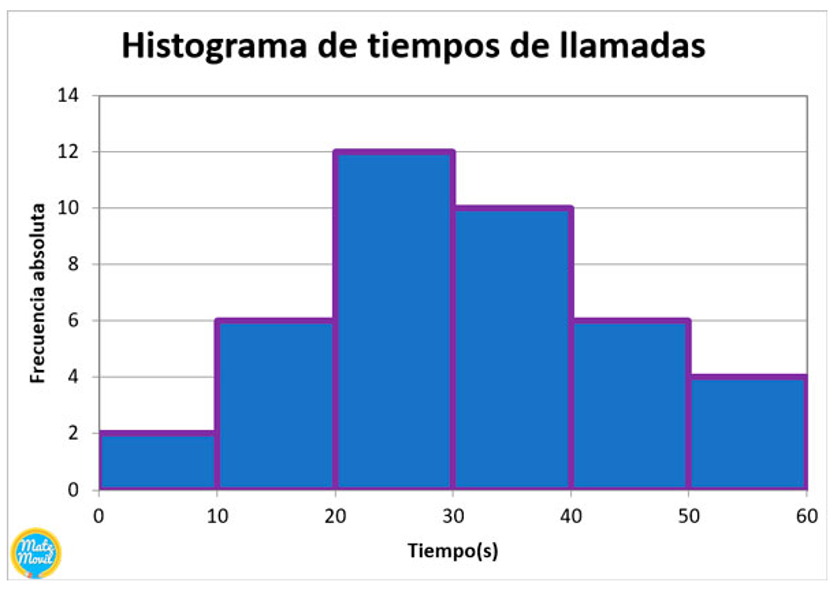


#### <font color="olive"> **¿Para qué sirve un histograma?**

* Analizar la distribución de los datos.

* Identificar asimetría (sesgo).

* Observar si los datos siguen una distribución conocida (por ejemplo, normal).

* Comparar distribuciones entre conjuntos de datos.

#### <font color="olive"> **¿Cómo creamos un histograma con *Matplotlib*?**

Matplotlib cuenta con la función`.hist()` que permite graficar histogramas (<https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html>). Sin embargo, a diferencia de los otros tipos de plots que hemos visto, <font color="brown"> **los histogramas no se pueden plotear directamente </font>**. Por lo que, *para crear un histograma es necesario seguir los siguientes pasos*:


1. Determinar los intervalos a representar, de tal manera que no se solapen.

2. Calcular la frecuencia de cada intervalo.

3. Una vez que tenemos los intervalos y las frecuencias calculadas solo resta hacer alguna representación gráfica.

---

Ahora sí, con este contexto vamos a crear nuestro primer histograma. 

#### <font color="darkorange"> **Paso 1 y Paso 2: Intervalos a representar y frecuencia de cada uno**

Tenemos una lista con diferentes edades y queremos conocer la frecuencia de dichas edades en 8 intervalos diferentes.

In [3]:
Edades=[12, 15, 13, 12, 18, 20, 19, 20, 13, 12, 13, 17, 15, 16, 13, 14, 13, 17, 19]

#Queremos dividir esa lista en 8 intervalos diferentes
#Podemos dividir en intervalos de dos maneras diferentes:
#(1) Definiendo la cantidad de intervalos, 
#(2) Definiendo los límites de cada intervalo

#### <font color="darkblue"> Forma 1: Definiendo la cantidad de intervalos

**`np.histogram()`** 
</font>(<https://numpy.org/doc/stable/reference/generated/numpy.histogram.html>)

La función `np.histogram()` de NumPy cuenta cuántos valores caen dentro de determinados intervalos (bins). A diferencia de `plt.hist()`, *np.histogram()* no genera una gráfica, sino que devuelve los conteos y los límites de los intervalos, lo cual resulta útil cuando se quiere realizar un análisis previo de los datos o construir gráficos personalizados.

In [4]:
Edades

[12, 15, 13, 12, 18, 20, 19, 20, 13, 12, 13, 17, 15, 16, 13, 14, 13, 17, 19]

In [10]:
#Forma 1:
# Necesitamos dos parámetros de entrada: Los datos y cuántos intervalos queremos
frecuencias= np.histogram(Edades, bins = 8) #bins nos ayuda a determinar los intervalos que queremos analizar

#¿Qué tipo de datos nos regresa?
print(frecuencias) # Es importante notar que cada intervalo incluye el límite inferior 
                   # y excluye el superior, excepto el último intervalo, que incluye ambos límites.

(array([3, 5, 1, 2, 1, 2, 1, 4]), array([12., 13., 14., 15., 16., 17., 18., 19., 20.]))


In [8]:
#Ahora quiero guardar por separado lo que regresa la función, ¿Cómo le hacemos?
frecuencias,intervalos= np.histogram(Edades, bins = 8) 
intervalos

array([12., 13., 14., 15., 16., 17., 18., 19., 20.])

In [11]:
#¿Y si quiero que el valor 19 y 20 se cuenten por separado?
#Para ello usamos el argumento "range" dentro de la función histogram()

frecuencias2=np.histogram(Edades,bins=9,range=(12,21)) #"range" permite definir desde qué valor hasta qué valor debe construir los intervalos (bins)
frecuencias2

(array([3, 5, 1, 2, 1, 2, 1, 2, 2]),
 array([12., 13., 14., 15., 16., 17., 18., 19., 20., 21.]))

#### <font color="darkblue"> Forma 2: Personalizar límites de los bins

In [16]:
# ¿Qué pasa si quieren hacer rangos personalizados?
# [10, 13) [13, 15) [15, 20]

frecuencia3, intervalos3 = np.histogram(Edades, bins=(10, 13, 15, 20)) # Puede ser con tupla o con lista, es importante que sus intervalos vayan incrementando
print(frecuencia3, intervalos3) 

[ 3  6 10] [10 13 15 20]


**Pueden personalizar sus bins definiéndolos directamente antes de graficar**

In [14]:
intervalos4=[10,13,16,19,22] #¿Y su frecuencia?
frecuencia3, intervalos3 = np.histogram(Edades, bins=intervalos4)
print(frecuencia3, intervalos3) 

[3 8 4 4] [10 13 16 19 22]


#### <font color="darkorange"> Ahora sí, ¡Vamos a graficar! 

#### <font color="darkorange"> **Ejemplo 1**


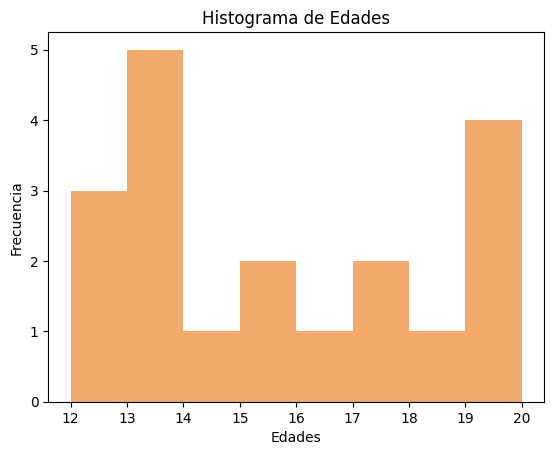

In [17]:
#Usando la función .hist() de Matplotlib, esta cuenta cuántos valores caen dentro de cada uno para construir las barras del histograma.

plt.hist(x = Edades, bins = intervalos, color = '#F2AB6D', rwidth = 1) #rwidth es el ancho de los rectángulos, por default 1
plt.title('Histograma de Edades')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')

plt.show()

#### <font color="darkorange"> **Ejemplo 2: Añadiendo contornos**

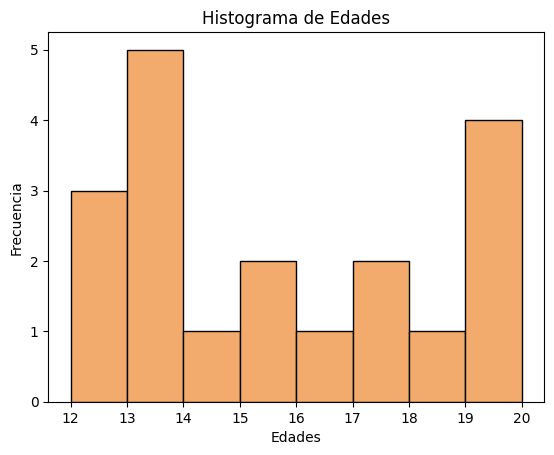

In [18]:
#Contorno a cada barra
plt.hist(x = Edades, bins = intervalos, color = '#F2AB6D', rwidth = 1, edgecolor="black")
plt.title('Histograma de Edades')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')
plt.show()

#### <font color="darkorange"> **Ejemplo 3: Frecuencias acumuladas**

[6 3 3 4] [13 15 17 19 21]


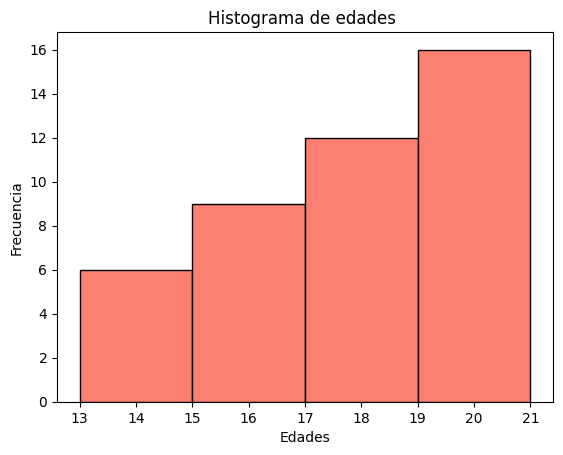

In [19]:
#También podemos acumular las frecuencias de los intervalos

intervalos5 = [13, 15, 17, 19, 21] # Defino mis intervalos

plt.hist(x = Edades, bins = intervalos5, color = 'salmon', cumulative = True,edgecolor="black") #, cumulative = True este hace que vaya acumulando los resultados para cada intervalo
plt.title('Histograma de edades ')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')

#np.histogram les puede servir para corroborar lo que están graficando
frecuencias_p, extremos_p = np.histogram(Edades, bins = intervalos5)
print(frecuencias_p, extremos_p) # Esto les puede servir para corroborar

[6 3 3 4] [13 15 17 19 21]


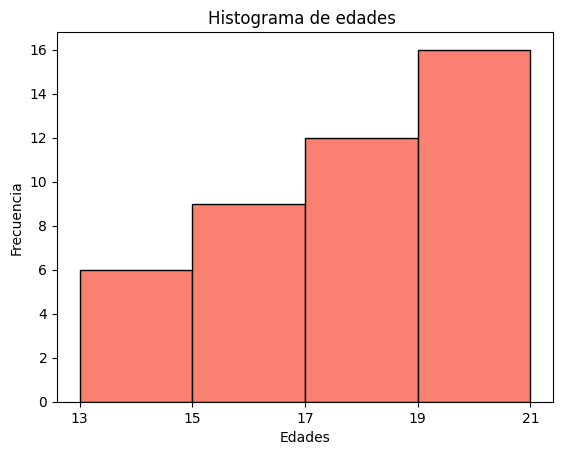

In [20]:
#Para que solo muestre los límites de los intervalos deben usar plt.xticks()

intervalos5 = [13, 15, 17, 19, 21] # Defino mis intervalos

plt.hist(x = Edades, bins = intervalos5, color = 'salmon', cumulative = True,edgecolor="black") #, cumulative = True este hace que vaya acumulando los resultados para cada intervalo
plt.title('Histograma de edades ')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')

#.ticks nos permite definir lo que queremos que sea nuestro eje x
plt.xticks(intervalos5)

#np.histogram les puede servir para corroborar lo que están graficando
frecuencias_p, extremos_p = np.histogram(Edades, bins = intervalos5)
print(frecuencias_p, extremos_p) 

#### <font color="darkorange"> **Ejemplo 5: Otras formas de dibujar histogramas**

####  <font color="darkorange">**1. Paso (step)**

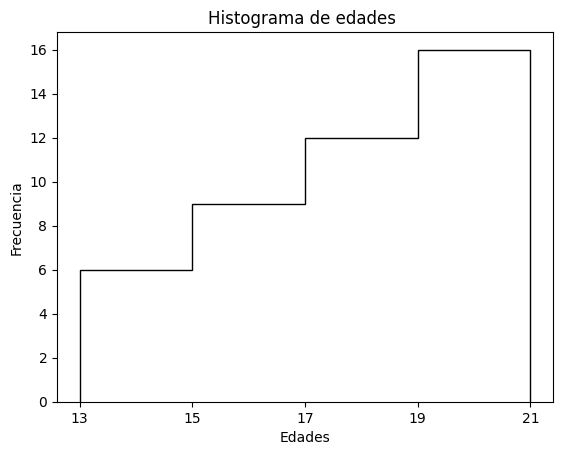

In [21]:
intervalos5 = [13, 15, 17, 19, 21] # Defino mis intervalos

plt.hist(x = Edades, bins = intervalos5,histtype="step", color="salmon", cumulative = True,edgecolor="black") 
plt.title('Histograma de edades ')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')


plt.xticks(intervalos5)
plt.show()

#### <font color="darkorange">**2. Pasos rellenos (stepfilled)**

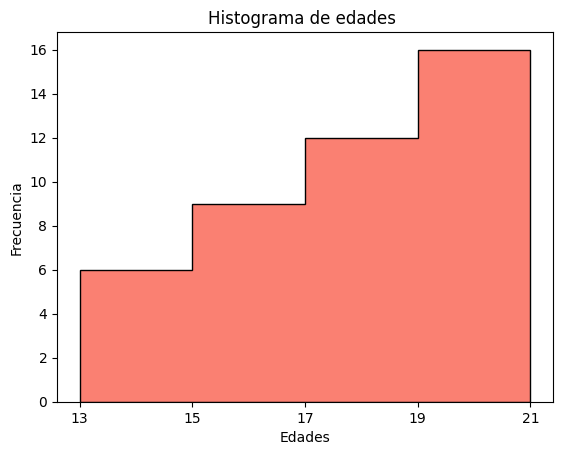

In [22]:
intervalos5 = [13, 15, 17, 19, 21] # Defino mis intervalos

plt.hist(x = Edades, bins = intervalos5,histtype="stepfilled", color="salmon", cumulative = True,edgecolor="black") 
plt.title('Histograma de edades ')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')


plt.xticks(intervalos5)
plt.show()

### <font color="brown"> Histogramas con varios grupos de datos

#### <font color="darkorange">Ejemplo 1: Grupos con el mismo rango de valores

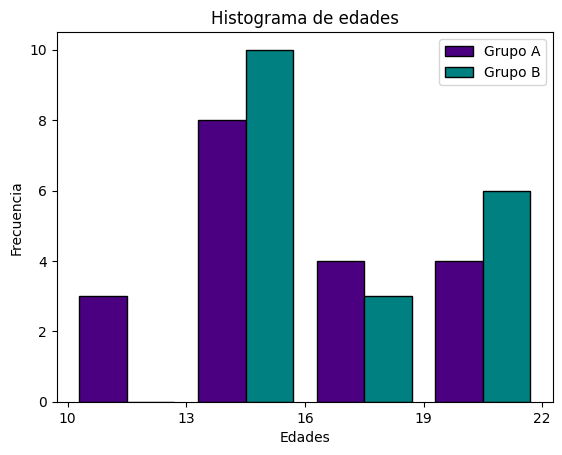

In [23]:
Edades_a = [12, 15, 13, 12, 18, 20, 19, 20, 13, 12, 13, 17, 15, 16, 13, 14, 13, 17, 19]
Edades_b = [20, 19, 17, 15, 15, 16, 13, 13, 19, 20, 20, 14, 15, 15, 18, 19, 13, 14, 15]

intervalos=[10, 13, 16, 19, 22]

#Cuando tengamos más de un grupo, debemos hacer una lista de las X y los colores
plt.hist(x = [Edades_a, Edades_b], bins = intervalos, color = ['indigo' , 'teal'],label=["Grupo A", "Grupo B"], edgecolor="black") 
plt.title('Histograma de edades')
plt.xlabel('Edades')
plt.legend()
plt.ylabel('Frecuencia')
plt.xticks(intervalos)
plt.show()

#### <font color="darkorange">Ejemplo 2: Grupos con diferentes rangos de valores

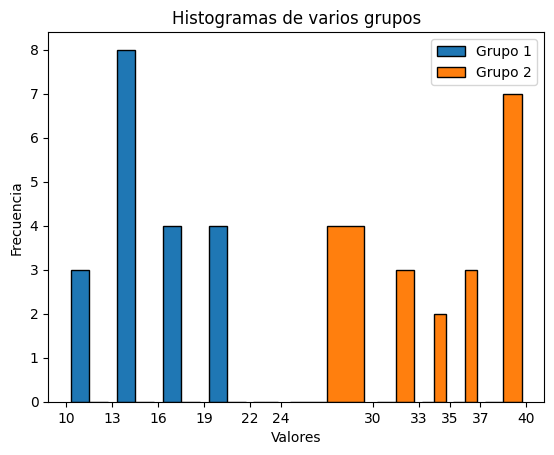

In [24]:
Edades_j = [12, 15, 13, 12, 18, 20, 19, 20, 13, 12, 13, 17, 15, 16, 13, 14, 13, 17, 19]
Edades_a = [33, 35, 28, 40, 37, 31, 25, 33, 28, 37, 40, 31, 35, 35, 28, 40, 37, 31, 40]

intervalos=[10, 13, 16,19,22,24,30,33,35,37,40]

#Podemos graficar datos diferentes en una misma línea
plt.hist([Edades_j, Edades_a], bins=intervalos,edgecolor="black",label=["Grupo 1","Grupo 2"])
plt.xlabel("Valores")
plt.ylabel("Frecuencia")
plt.legend()
plt.xticks(intervalos)
plt.title("Histogramas de varios grupos")
plt.show()

**¿Cómo lo interpretarían?**

El gráfico evidencia dos poblaciones con rangos de edad completamente diferentes, lo que produce dos distribuciones separadas en el histograma. Esto indica que los grupos pertenecen a etapas de edad distintas, sin solapamiento entre ellas. 

<font color="brown"> OJO: Elegir el número correcto de bins es importante porque afecta la interpretación. Muy pocos bins: se pierde información. Demasiados bins: el gráfico se vuelve ruidoso.

### <font color="darkblue"> **Barras apiladas**

En los histogramas, las barras apiladas permiten mostrar varios grupos de datos en los mismos intervalos, pero en lugar de superponerse, las frecuencias de cada grupo se suman verticalmente dentro de cada bin. Esto facilita observar la contribución de cada grupo al total de datos en cada intervalo.

Las barras apiladas se obtienen utilizando el parámetro `stacked=True` en la función `plt.hist()`.

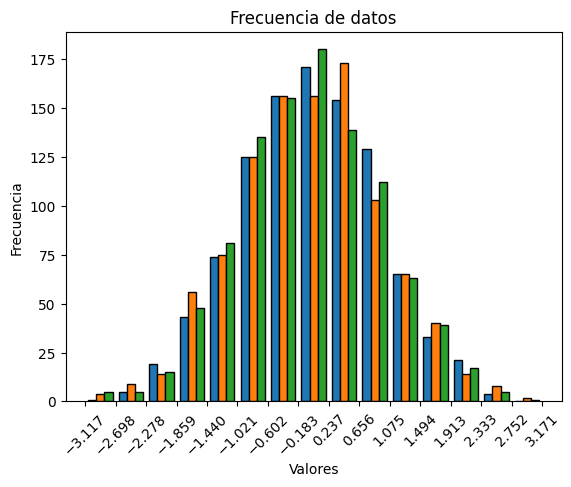

In [25]:
# Crearemos un array de números aleatorios 
np.random.seed(0)
x = np.random.randn(1000,3) #1000 filas  y 3 columnas (Por lo tanto son 3 grupos diferentes)

_,inter=np.histogram(x,bins=15)

plt.hist(x,bins=inter,edgecolor="black") 
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.xticks(inter,rotation=45)
plt.title('Frecuencia de datos')
plt.show()

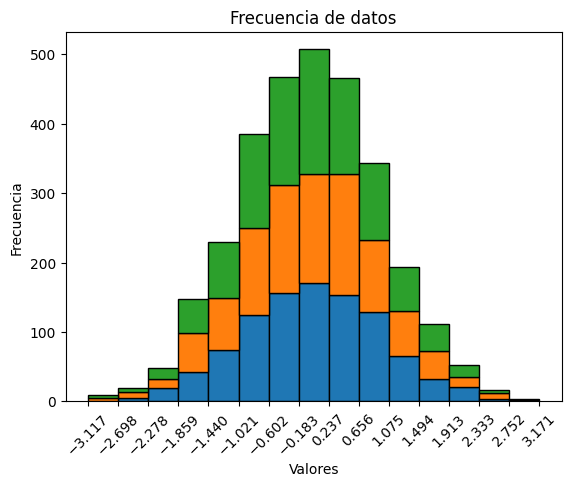

In [26]:
#Esto hace que se encime uno en otro
_,inter=np.histogram(x,bins=15)

plt.hist(x,bins=inter,edgecolor="black",stacked=True) 
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.xticks(inter,rotation=45)
plt.title('Frecuencia de datos')
plt.show()

<font color="brown">**Resumen de diferencias entre histogramas y gráficos de barra**

|Histograma|Gráfico de barras|
|-----------|-------|
|Datos continuos|Datos categóricos|
|Barras pegadas	|Barras separadas|
|Intervalos|Categorías|


#### <font color="orange"> **Ejemplo: Precipitación de dos regiones**

Supongamos que tenemos registros de precipitación diaria de dos regiones de México durante un periodo

- Región A: zona semiárida
- Región B: zona tropical

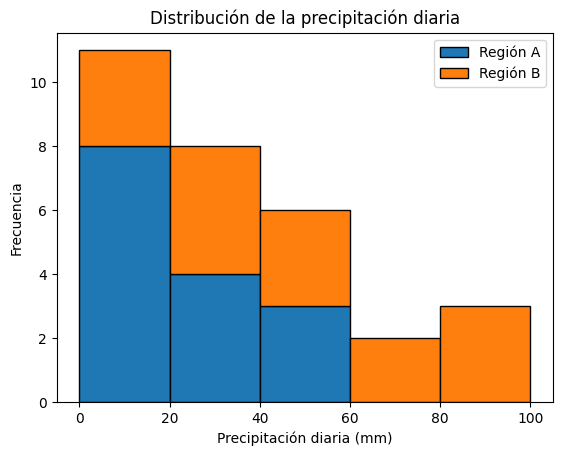

In [2]:
import matplotlib.pyplot as plt
precipitacion_A = [0, 2, 5, 8, 10, 12, 15, 18, 20, 25,30, 35, 40, 45, 50]

precipitacion_B = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50,60, 70, 80, 90, 100]

plt.hist([precipitacion_A, precipitacion_B],bins=5,stacked=True,edgecolor="black",label=["Región A", "Región B"])

plt.xlabel("Precipitación diaria (mm)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la precipitación diaria")
plt.legend()

plt.show()

La altura completa de la barra indica cuántos días se encuentran dentro de ese intervalo de precipitación, mientras que cada sección de la barra indica cuántos días corresponden a cada región.

-----

### <font color="purple">Ejercicio 1: Costera vs Continental

1. Define dos grupos de datos de temperatura (20 datos), uno para la zona costera y otro para la zona continental.
2. Realiza un histograma para cada tipo de dato.
3. Grafica ambos histogramas en la misma figura.

In [ ]:
#Punto 1
temp_costera=np.random.uniform(30,40,20)
temp_continental=np.random.uniform(20,35,20)

In [ ]:
#Punto2
plt.hist(temp_costera,bins=[30,32,34,36,38,40],rwidth = 1, edgecolor="black",color="brown")
plt.xlabel("Temperaturas $^\circ$C")
plt.ylabel("Cuenta")
plt.title("Costera")
plt.show()

In [ ]:
plt.hist(temp_continental,bins=[20,22,24,26,28,30,32,34,36],rwidth = 1, edgecolor="black",color="teal")
plt.xlabel("Temperaturas $^\circ$C")
plt.ylabel("Cuenta")
plt.title("Continental")
plt.show()

In [ ]:
#Punto3
plt.hist([temp_continental,temp_costera],bins=[20,22,24,26,28,30,32,34,36,38,40],rwidth = 1, edgecolor="black",label=["Continental","Costera"],color=["teal","brown"])
plt.xlabel("Temperaturas $^\circ$C")
plt.ylabel("Cuenta")
plt.legend()
plt.title("Continental y costera")
plt.xticks([20,22,24,26,28,30,32,34,36,38,40])
plt.show()


------------

# <font color="darkblue"> Gráfico de bigotes (boxplot)

Los gráficos de bigotes son una herramienta utilizada para **resumir la distribución de un conjunto de datos mediante medidas estadísticas clave**.
*Este tipo de gráfico muestra el valor mínimo, el primer cuartil (Q1), la mediana, el tercer cuartil (Q3) y el valor máximo*, lo que **permite visualizar de manera rápida la tendencia central, la dispersión y la presencia de valores atípicos (outliers)**. 


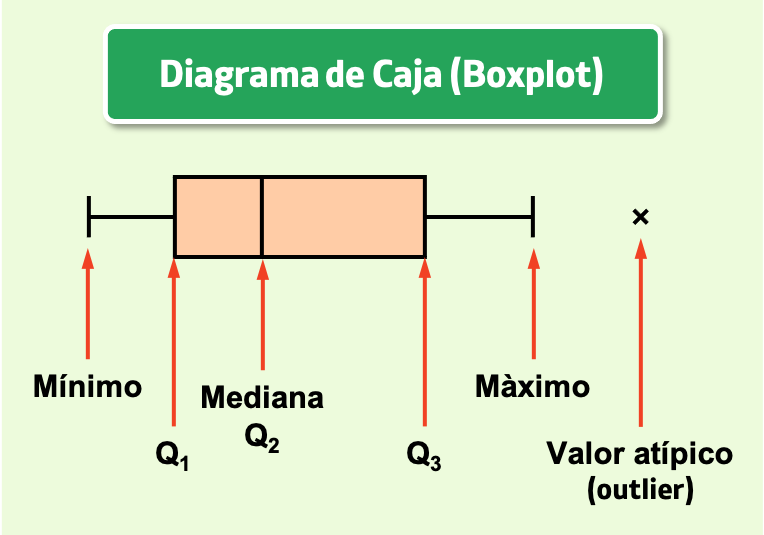

#### <font color="olive"> **¿Para qué sirve un boxplot?**

* Identificar la tendencia central de los datos mediante la mediana.

* Analizar la variabilidad o dispersión de los datos.

* Detectar valores atípicos que pueden representar errores o eventos extremos.

* Comparar rápidamente múltiples conjuntos de datos.

 #### <font color="olive"> **¿Cómo creamos un boxplot?** 

En Matplotlib, estos gráficos se pueden generar fácilmente con la función `plt.boxplot()` (<https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html>).

¡Vamos a hacer nuestra primera gráfica de bigotes! :)

#### <font color="darkorange"> **Ejemplo 1: Humedad del suelo**

In [2]:
#Vamos a crear valores random de humedad del suelo
np.random.seed(42)
humedad= np.random.uniform(35, 50, 100)
humedad

array([40.61810178, 49.2607146 , 45.97990913, 43.97987726, 37.34027961,
       37.33991781, 35.87125418, 47.99264219, 44.01672518, 45.62108867,
       35.30876741, 49.54864778, 47.48663961, 38.18508666, 37.72737451,
       37.75106765, 39.56363364, 42.87134647, 41.47917528, 39.3684371 ,
       44.17779342, 37.09240791, 39.38216973, 40.49542765, 41.84104976,
       46.77763942, 37.99510673, 42.71351658, 43.88621853, 35.69675619,
       44.11317278, 37.55786186, 35.97577389, 49.23328306, 49.4844805 ,
       47.12596022, 39.56920654, 36.46508171, 45.2634954 , 41.60228741,
       36.83057352, 42.42765365, 35.51582782, 48.63980603, 38.88169972,
       44.93783427, 39.67566614, 42.80102032, 43.20065419, 37.77281683,
       49.54376942, 46.62699235, 49.09248412, 48.42241026, 43.96849968,
       48.82811353, 36.32738753, 37.93974294, 35.67840933, 39.87995496,
       40.83015935, 39.07023548, 47.43106264, 40.3512999 , 39.21401765,
       43.14044125, 37.11386337, 47.03295471, 36.11825966, 49.80

**Antes de graficar, podemos conocer el comportamiento de los datos mediante los cuartiles. Para ello, usamos la función `quantile()` de NumPy.**

In [3]:
#Cuartile
quantiles = np.quantile(humedad, np.array([0.00, 0.25, 0.50, 0.75, 1.00])) #(datos,cuantiles que quiero conocer)

print(quantiles)

[35.08283176 37.89801141 41.96213682 45.95304679 49.80330405]


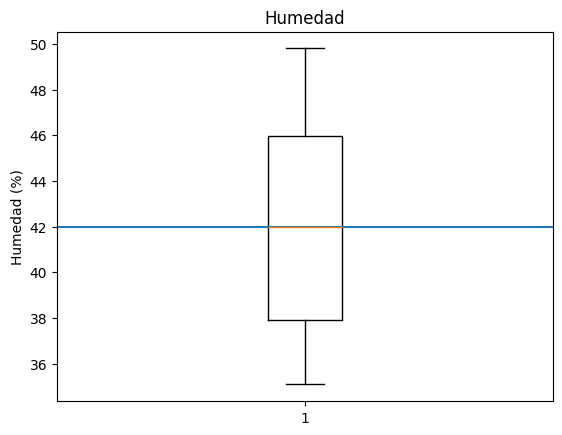

In [7]:
#Boxplot sencillo

plt.boxplot(humedad)

#Personalización
plt.title("Humedad")
plt.axhline(41.962)
plt.ylabel("Humedad (%)")
plt.show()

#¿Qué me podrían decir de la gráfica?

**La gráfica anterior, es muy idealista. Ya que en muchas ocasiones se van a topar con datos que contengas outliers.**

#### <font color="orange"> **Ejemplo 2: Outliers**


In [8]:
#Vamos a agregar valores atípicos a nuestros datos de humedad
outliers=np.array([80.0,75.0,60.0])

#Vamos a unir nuestro array original con los outliers
humedad_extremos = np.concatenate([humedad, outliers]) #np.concatenate() nos permite unir arrays en uno solo

In [9]:
humedad_extremos

array([40.61810178, 49.2607146 , 45.97990913, 43.97987726, 37.34027961,
       37.33991781, 35.87125418, 47.99264219, 44.01672518, 45.62108867,
       35.30876741, 49.54864778, 47.48663961, 38.18508666, 37.72737451,
       37.75106765, 39.56363364, 42.87134647, 41.47917528, 39.3684371 ,
       44.17779342, 37.09240791, 39.38216973, 40.49542765, 41.84104976,
       46.77763942, 37.99510673, 42.71351658, 43.88621853, 35.69675619,
       44.11317278, 37.55786186, 35.97577389, 49.23328306, 49.4844805 ,
       47.12596022, 39.56920654, 36.46508171, 45.2634954 , 41.60228741,
       36.83057352, 42.42765365, 35.51582782, 48.63980603, 38.88169972,
       44.93783427, 39.67566614, 42.80102032, 43.20065419, 37.77281683,
       49.54376942, 46.62699235, 49.09248412, 48.42241026, 43.96849968,
       48.82811353, 36.32738753, 37.93974294, 35.67840933, 39.87995496,
       40.83015935, 39.07023548, 47.43106264, 40.3512999 , 39.21401765,
       43.14044125, 37.11386337, 47.03295471, 36.11825966, 49.80

In [10]:
humedad_extremos
quantiles = np.quantile(humedad_extremos, np.array([0.00, 0.25, 0.50, 0.75, 1.00])) 
quantiles

array([35.08283176, 37.96023908, 42.40693395, 46.48814171, 80.        ])

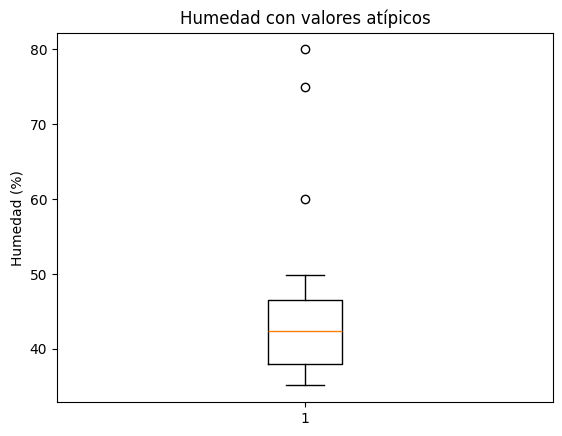

In [11]:
plt.boxplot(humedad_extremos)

plt.title("Humedad con valores atípicos")
plt.ylabel("Humedad (%)")
plt.show()

#### <font color="orange"> **Ejemplo 3: Varios grupos de datos**

In [12]:
#Vamos a crear valores random de humedad del suelo
np.random.seed(5)
humedad_bosque = np.random.uniform(35, 50, 100)
humedad_pastizal = np.random.uniform(25, 40, 100)
humedad_agricola = np.random.uniform(15, 35, 100)

#Vamos a agregar algunos outliers

humedad_bosque=np.concatenate([humedad_bosque,np.array([69,60])])
humedad_pastizal=np.concatenate([humedad_pastizal,np.array([69,75])])
humedad_agricola=np.concatenate([humedad_agricola,np.array([50,65])])

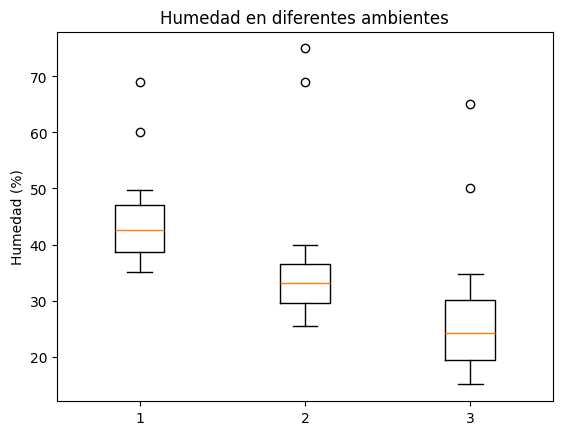

In [13]:
#Ahora vamos a graficarlo

#Paso 1: Crear una lista con los datos a graficar

datos=[humedad_bosque,humedad_pastizal,humedad_agricola]

#Paso2: Graficar

plt.boxplot(datos)
plt.title("Humedad en diferentes ambientes")
plt.ylabel("Humedad (%)")
plt.show()

### <font color="darkblue"> **Personalización de los boxplots**

#### <font color="darkorange"> **Ejemplo 1: Etiquetas**

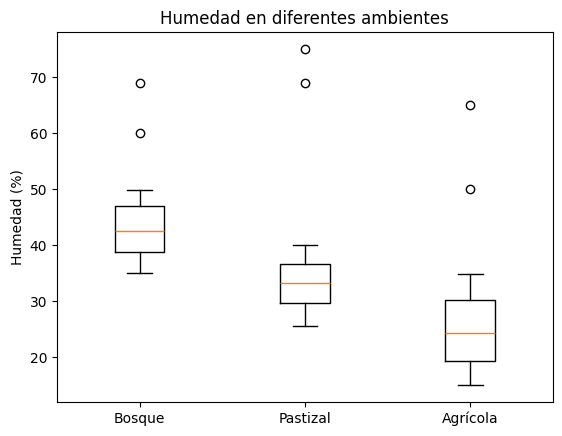

In [14]:
# Etiquetas

plt.boxplot(datos, tick_labels=["Bosque","Pastizal","Agrícola"])
plt.title("Humedad en diferentes ambientes")
plt.ylabel("Humedad (%)")
plt.show()

#### <font color="darkorange"> **Ejemplo 2: Orientación**

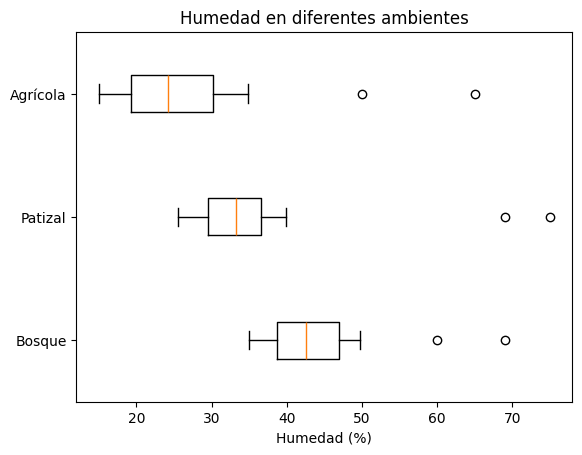

In [15]:
#Orientación del gráfico

plt.boxplot(datos, tick_labels=["Bosque","Patizal","Agrícola"],vert=False) #False: Horizontal, True: Vertical
plt.title("Humedad en diferentes ambientes")
plt.xlabel("Humedad (%)")
plt.show()

#### <font color="darkorange"> **Ejemplo 3: Media y valores atípicos**

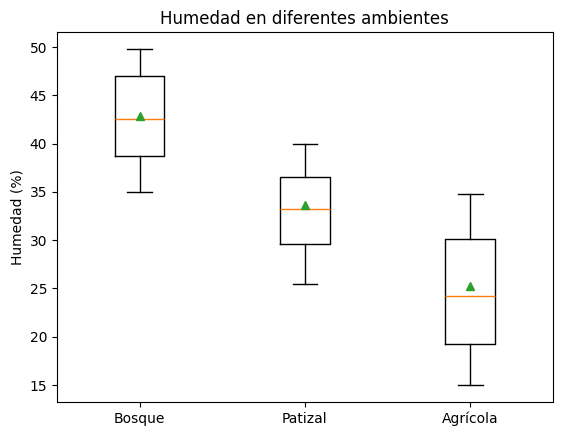

In [16]:
#Mostrar la media de los datos(showmeans), quitar valores atípicos (showfliers)

plt.boxplot(datos, tick_labels=["Bosque","Patizal","Agrícola"],
            vert=True,
           showmeans=True, #La media aparece como un símbolo adicional dentro del boxplot
           showfliers=False  #False quita los outliers
           ) 
plt.title("Humedad en diferentes ambientes")
plt.ylabel("Humedad (%)")
plt.show()

#### <font color="darkorange"> **Ejemplo 4: Estilos de cajas y media**

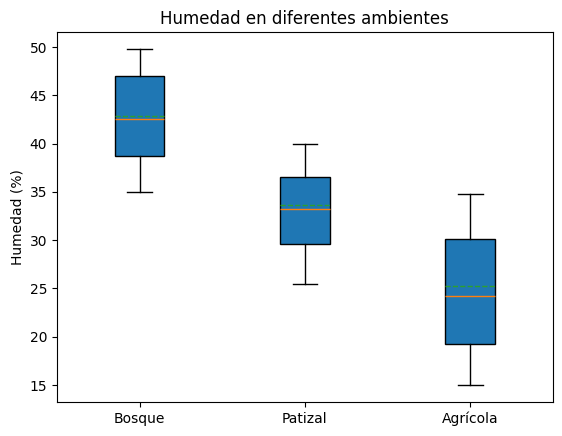

In [19]:
# Quiero colorear las cajas y cambiar el símbolo de la media por una línea

plt.boxplot(datos, tick_labels=["Bosque","Patizal","Agrícola"],
            vert=True,
           showmeans=True, 
           showfliers=False,  
           patch_artist=True, #Colorear las cajas
            meanline=True #Colocar línea punteada el valor del promedio
           ) 
plt.title("Humedad en diferentes ambientes")
plt.ylabel("Humedad (%)")
plt.show()

#### <font color="darkorange"> **Ejemplo 5: Colores**

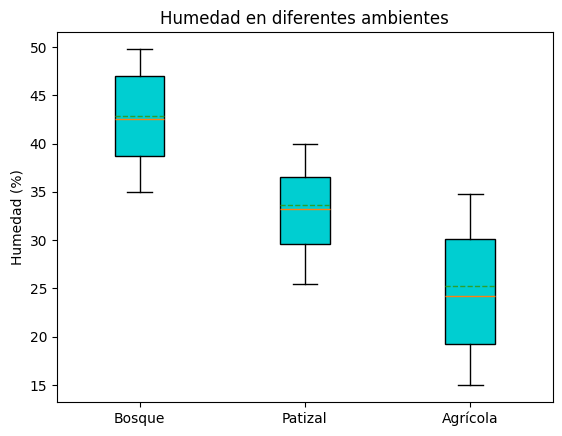

In [20]:
#Colores específicos

# Para cambiar los colores es muy importante poner el patch_artist si no, nos va a salir un error
plt.boxplot(datos, tick_labels=["Bosque","Patizal","Agrícola"],
            vert=True,
           showmeans=True,
           showfliers=False,  
           patch_artist=True, 
            meanline=True,
            boxprops = dict(facecolor= 'darkturquoise') #Personalizar los col
           ) 
plt.title("Humedad en diferentes ambientes")
plt.ylabel("Humedad (%)")
plt.show()


#### <font color="darkorange"> **Ejemplo 6: Color a la mediana, media, y de los bigotes**

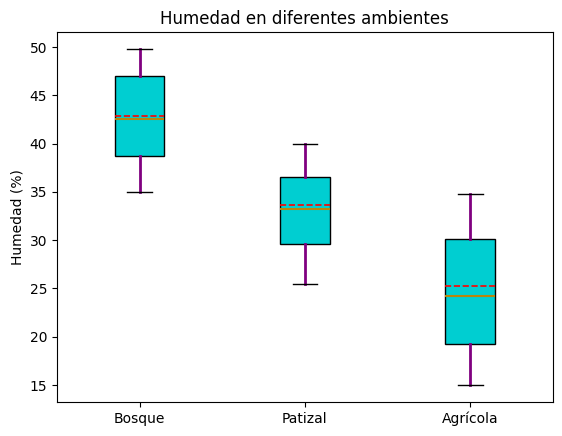

In [21]:
#Definir color a la mediana, media, y de los bigotes

plt.boxplot(datos, tick_labels=["Bosque","Patizal","Agrícola"],vert=True,showmeans=True,
           showfliers=False,  
           patch_artist=True, 
            meanline=True,
            boxprops = dict(facecolor= 'darkturquoise'),
            medianprops = dict(color = "darkgoldenrod", linewidth = 1.5), #Personalizar mediana
            meanprops = dict(color = "red", linewidth = 1.2),#Personalizar promedio
            whiskerprops = dict(color = "purple", linewidth = 2)#Personalizar bigotes
           ) 
plt.title("Humedad en diferentes ambientes")
plt.ylabel("Humedad (%)")
plt.show()


#### <font color="darkorange">**Ejemplo 7: Definir color de los extremos y modificar outliers**

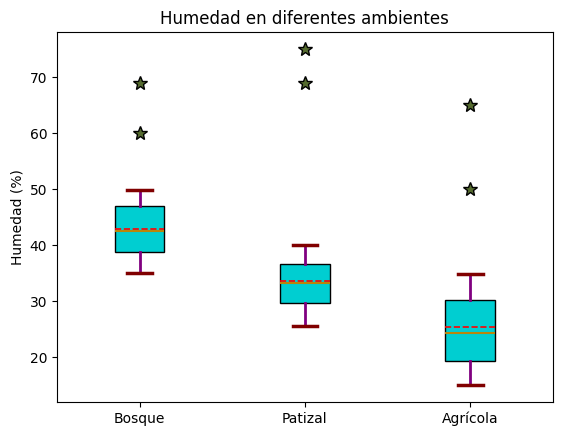

In [22]:
#Definir color de los extremos y modificar outliers

plt.boxplot(datos, tick_labels=["Bosque","Patizal","Agrícola"],vert=True,showmeans=True,
           showfliers=True,  
           patch_artist=True, 
            meanline=True,
            boxprops = dict(facecolor= 'darkturquoise'),
            medianprops = dict(color = "darkgoldenrod", linewidth = 1.5), 
            meanprops = dict(color = "red", linewidth = 1.2),
            whiskerprops = dict(color = "purple", linewidth = 2),
            capprops = dict(color = "maroon", linewidth = 2.5), #Personalizar extremos
            flierprops = dict(marker = '*', markersize = 10, markerfacecolor = 'darkolivegreen')#Personalizar outliers
           ) 
plt.title("Humedad en diferentes ambientes")
plt.ylabel("Humedad (%)")
plt.show()



<font color="brown"> **Cuando hay valores `NaN` en los datos, los boxplots en Matplotlib pueden comportarse de dos formas: pueden ignorar automáticamente algunos valores o el gráfico puede no mostrarse correctamente si hay muchos `NaN`. Por eso normalmente se recomienda tratarlos antes de hacer el gráfico.**

### <font color="purple"> **Ejercicio 2**

Utilizando los datos de *gas_prices.csv*:

* Encuentra e imprime $Q1$, $Q2$, $Q3$ y los límites (máximo y mínimo) de los precios del gas por país usando un ciclo for.
* Realiza dos gráficas, con y sin outliers, de los boxplots de los precios del gas por país.
* Personaliza tu gráfica lo más que puedas.


In [23]:
#Cargando los datos
gas=pd.read_csv("/home/jovyan/Clase/TemasSelectos/data/gas_prices.csv")
gas

,Year,Australia,Canada,France,Germany,Italy,Japan,Mexico,South Korea,UK,USA
0,1990,NaN,1.87,3.63,2.65,4.59,3.16,1.00,2.05,2.82,1.16
1,1991,1.96,1.92,3.45,2.90,4.50,3.46,1.30,2.49,3.01,1.14
2,1992,1.89,1.73,3.56,3.27,4.53,3.58,1.50,2.65,3.06,1.13
3,1993,1.73,1.57,3.41,3.07,3.68,4.16,1.56,2.88,2.84,1.11
4,1994,1.84,1.45,3.59,3.52,3.70,4.36,1.48,2.87,2.99,1.11
5,1995,1.95,1.53,4.26,3.96,4.00,4.43,1.11,2.94,3.21,1.15
6,1996,2.12,1.61,4.41,3.94,4.39,3.64,1.25,3.18,3.34,1.23
7,1997,2.05,1.62,4.00,3.53,4.07,3.26,1.47,3.34,3.83,1.23
8,1998,1.63,1.38,3.87,3.34,3.84,2.82,1.49,3.04,4.06,1.06
9,1999,1.72,1.52,3.85,3.42,3.87,3.27,1.79,3.80,4.29,1.17


In [26]:
#Cuartiles por cada país

#Vamos a colocar como índices los años
gas.index=gas.Year
gas_nuevo=gas.drop("Year",axis=1)

#Eliminamos valores nan
gas_nuevo=gas_nuevo.dropna()

#Obteniendo los nombres de los paises
paises=gas_nuevo.columns

print(paises)
#Obteniendo los cuartiles

for i in paises:
    
    quantiles_gas = np.quantile(gas_nuevo[i], np.array([0.00, 0.25, 0.50, 0.75, 1.00])) 
    print(i,"Cuartiles:",quantiles_gas)


Index(['Australia', 'Canada', 'France', 'Germany', 'Italy', 'Japan', 'Mexico',
       'South Korea', 'UK', 'USA'],
      dtype='object')
Australia Cuartiles: [1.63   1.78   1.955  2.5875 4.45  ]
Canada Cuartiles: [1.38  1.58  1.725 2.275 4.08 ]
France Cuartiles: [3.41   3.5975 3.935  4.845  7.51  ]
Germany Cuartiles: [2.9    3.405  3.6    5.0775 7.75  ]
Italy Cuartiles: [3.57   3.7875 4.23   5.1    7.63  ]
Japan Cuartiles: [2.82   3.3175 3.645  4.34   5.74  ]
Mexico Cuartiles: [1.11   1.4825 1.9    2.215  2.45  ]
South Korea Cuartiles: [2.49   2.965  3.78   4.4275 6.21  ]
UK Cuartiles: [2.84   3.2425 4.145  5.345  7.42  ]
USA Cuartiles: [1.06   1.1425 1.295  1.8075 3.27  ]


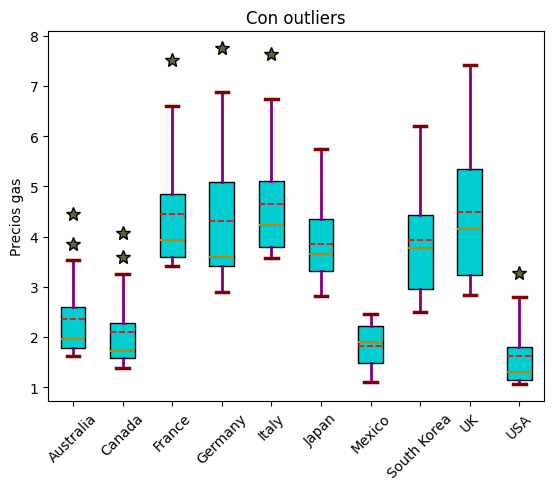

In [29]:
#Punto2
plt.boxplot(gas_nuevo, tick_labels=paises,vert=True,showmeans=True,
           showfliers=True,  
           patch_artist=True, 
            meanline=True,
            boxprops = dict(facecolor= 'darkturquoise'),
            medianprops = dict(color = "darkgoldenrod", linewidth = 1.5), 
            meanprops = dict(color = "red", linewidth = 1.2),
            whiskerprops = dict(color = "purple", linewidth = 2),
            capprops = dict(color = "maroon", linewidth = 2.5), #Personalizar extremos
            flierprops = dict(marker = '*', markersize = 10, markerfacecolor = 'darkolivegreen')#Personalizar outliers
           ) 
plt.title("Con outliers")
plt.xticks(rotation=45)
plt.ylabel("Precios gas")
plt.show()


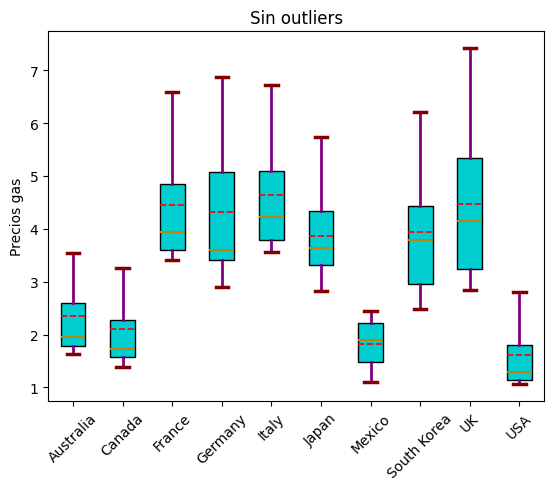

In [30]:
#Punto2
plt.boxplot(gas_nuevo, tick_labels=paises,vert=True,showmeans=True,
           showfliers=False,  
           patch_artist=True, 
            meanline=True,
            boxprops = dict(facecolor= 'darkturquoise'),
            medianprops = dict(color = "darkgoldenrod", linewidth = 1.5), 
            meanprops = dict(color = "red", linewidth = 1.2),
            whiskerprops = dict(color = "purple", linewidth = 2),
            capprops = dict(color = "maroon", linewidth = 2.5), #Personalizar extremos
            flierprops = dict(marker = '*', markersize = 10, markerfacecolor = 'darkolivegreen')#Personalizar outliers
           ) 
plt.title("Sin outliers")
plt.xticks(rotation=45)
plt.ylabel("Precios gas")
plt.show()
